In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

csv = 'newlsamples500_2'

encodings_csv = '../encodings/normalized_encodings_' + csv + '.csv'
features_csv = '../node_features.csv'

encodings = pd.read_csv(encodings_csv)
features = pd.read_csv(features_csv)
encodings.columns = ['identifier'] + list(encodings.columns[1:])
features.columns = ['identifier'] + list(features.columns[1:])
encodings = encodings.dropna(axis='index')
matching_ids = set(encodings['identifier']) & set(features['identifier'])

encodings = encodings[encodings['identifier'].isin(matching_ids)]
encodings = encodings.sort_values('identifier').reset_index(drop=True)
features = features[features['identifier'].isin(matching_ids)]
features = features.sort_values('identifier').reset_index(drop=True)

encodings = pd.DataFrame(normalize(encodings.iloc[:, 1:], 'l2', axis=1))

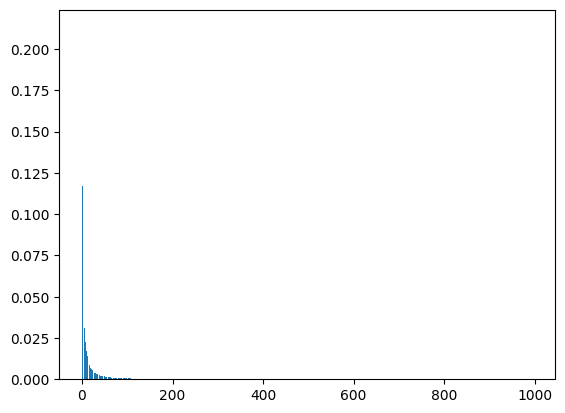

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components='mle')
W_pca = pca.fit_transform(encodings)
variance = pca.explained_variance_ratio_
plt.figure()
plt.bar(list(range((pca.n_components_))), variance)
plt.show()


In [ ]:
pri_axes = pca.components_
basis_dim = pri_axes[1, :]
point = encodings.mean(axis=0) + 0.5*basis_dim
point.to_csv('point.csv')

In [ ]:

#import matplotlib.pyplot as plt
feature = 'ASA'
characteristic = 0.90
res_labels = features.index[features[feature] > characteristic]
ASA_encodings = encodings.loc[res_labels]
high_mean = ASA_encodings.mean(axis=0)

feature = 'ASA'
characteristic = 0.10
res_labels = features.index[features[feature] < characteristic]
low_ASA_encodings = encodings.loc[res_labels]
low_mean = low_ASA_encodings.mean(axis=0)

#ASA_basis_dim = high_ASA_basis_dim - low_ASA_basis_dim
ASA_basis_dim = -2*(high_mean - low_mean)

'''
import skfda
from skfda import FDataGrid

threshold = 0.01

feature = 'ASA'
characteristic = 0.1
res_labels = features.iloc[:, 0][features[feature] < characteristic]

ASA_encodings = encodings.loc[res_labels.index]
ASA_encodings = ASA_encodings.reset_index(drop=True)
stdv = ASA_encodings.std(axis=0)
mean = ASA_encodings.mean(axis=0)
ASA_basis_dim = pd.Series(0.0, index=mean.index)
ASA_basis_dim[stdv < threshold] = mean[stdv < threshold]




#print(ASA_basis_dim[:20])
'''

In [6]:
"""feature = 'sec_struct'
characteristic = 'E'
res_labels = features.iloc[:, 0][features[feature] == characteristic]
SS_encodings = encodings.loc[res_labels.index]
SS_encodings = SS_encodings.reset_index(drop=True)
#print(ASA_encodings.iloc[:5, :5])
stdv = SS_encodings.std(axis=0)
#print(stdv[:5])
mean = SS_encodings.mean(axis=0)
#print(mean[:5])
SS_basis_dim = pd.Series(0.0, index=mean.index)
SS_basis_dim[stdv < threshold] = mean[stdv < threshold]
SS_basis_dim = mean
#X = FDataGrid(SS_encodings.values)
#median = skfda.exploratory.stats.geometric_median(X)
#print(median.data_matrix[0].shape)

#SS_basis_dim = median.data_matrix[0]"""
'''
feature = 'sec_struct'
characteristic = 'I'
res_labels = features.index[features[feature] == characteristic]
yes_SS_encodings = encodings.loc[res_labels]

stdv = yes_SS_encodings.std(axis=0)
high_mean = yes_SS_encodings.mean(axis=0)
yes_SS_basis_dim = pd.Series(0.0, index=high_mean.index)
yes_SS_basis_dim[stdv < 0.05] = high_mean[(stdv < 0.05)]

feature = 'sec_struct'
characteristic = 'I'
res_labels = features.index[features[feature] != characteristic]
not_SS_encodings = encodings.loc[res_labels]

stdv = not_SS_encodings.std(axis=0)
low_mean = not_SS_encodings.mean(axis=0)
not_SS_basis_dim = pd.Series(0.0, index=low_mean.index)
not_SS_basis_dim[stdv < 0.05] = low_mean[(stdv < 0.05)]
'''
#SS_basis_dim = yes_SS_basis_dim - not_SS_basis_dim

feature = 'bfactor'
characteristic = 50
res_labels = features.index[features[feature] > characteristic]
yes_SS_encodings = encodings.loc[res_labels]
stdv = yes_SS_encodings.std(axis=0)
high_mean = yes_SS_encodings.mean(axis=0)

characteristic = 10
res_labels = features.index[features[feature] < characteristic]
not_SS_encodings = encodings.loc[res_labels]
low_mean = not_SS_encodings.mean(axis=0)

SS_basis_dim = -2*(high_mean - low_mean)

point = SS_basis_dim# + ASA_basis_dim
point.to_csv('point.csv')

In [4]:
'''
mask = stdv < 0.063
masked_e = encodings.loc[:, mask]
print(masked_e.shape)
#print(stdv[90:100])
#print(mean[90:100])

print(max(masked_e.mean(axis=0)))

fig, ax = plt.subplots()
im = ax.imshow(encodings.iloc[:25, 60:100], cmap='viridis')
fig.colorbar(im, ax=ax)
plt.show()

plt.figure()
plt.imshow(masked_e.iloc[:25, :100])
plt.show()

plt.figure()
plt.imshow(encodings.iloc[:25, pd.Series(np.where([stdv < 0.01])[1])[:128]])
plt.show()

plt.figure()
plt.imshow(basis_dim[:128].to_frame().T)
plt.show()

plt.hist(stdv, bins=20)
plt.show()
'''

"\nmask = stdv < 0.063\nmasked_e = encodings.loc[:, mask]\nprint(masked_e.shape)\n#print(stdv[90:100])\n#print(mean[90:100])\n\nprint(max(masked_e.mean(axis=0)))\n\nfig, ax = plt.subplots()\nim = ax.imshow(encodings.iloc[:25, 60:100], cmap='viridis')\nfig.colorbar(im, ax=ax)\nplt.show()\n\nplt.figure()\nplt.imshow(masked_e.iloc[:25, :100])\nplt.show()\n\nplt.figure()\nplt.imshow(encodings.iloc[:25, pd.Series(np.where([stdv < 0.01])[1])[:128]])\nplt.show()\n\nplt.figure()\nplt.imshow(basis_dim[:128].to_frame().T)\nplt.show()\n\nplt.hist(stdv, bins=20)\nplt.show()\n"